<div style="background:linear-gradient(to right,#0f2027,#203a43,#2c5364);
padding:25px;border-radius:15px;">

<h1 style="color:white;text-align:center;font-size:42px;">
🌍 Air Quality Analysis and AQI Prediction
</h1>

<p style="color:white;text-align:center;font-size:20px;">
INT557 – Data Science with Python Project
</p>

<p style="color:white;text-align:center;font-size:16px;">
Exploratory Data Analysis | Machine Learning | Statistical Analysis | Business Insights
</p>

</div>

## Project Overview

**Course:** INT557 – Data Science with Python  
**Project Title:** Air Quality Analysis and AQI Prediction using Python

This project explores air quality data from India to identify pollution patterns, health impacts, and predictive factors. It combines data cleaning, visualization, statistical analysis, and machine learning to deliver actionable insights.

### Objectives

Objective
1.  Import required libraries and set up environment
2.  Load and understand four real-world datasets
3.  Data cleaning and preprocessing
4.  Exploratory Data Analysis (EDA) with visualizations
5.  Vehicle registration and EV adoption analysis
6.  Disease and health impact analysis
7.  Statistical and correlation analysis
8.  Machine Learning – Regression models
9. Machine Learning – Classification models
10.  Unsupervised Learning (K-Means Clustering)

### Datasets Used

- **AQI Dataset** – Day-wise, state-wise AQI for major Indian cities (425,971 records)
- **Disease Dataset** – State/district-wise disease outbreak cases (26,559 records)
- **Vehicle Dataset** – State-wise vehicle registration by fuel type (199,552 records)


## Import Required Libraries

In [34]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)



## Load and Understand the Datasets

Understanding shape, column names, and data types is the first step before any analysis.

<div style="background-color:#2E7D32;
padding:12px;
border-radius:10px;">

<h2 style="color:white;">
📂 Dataset Loading and Understanding
</h2>

</div>

In [35]:
AQI_PATH       = 'dataset/day-wise-state-wise-air-quality-index-aqi-of-major-cities-and-towns-in-india.csv'
DISEASE_PATH   = 'dataset/master-data-state-district-and-disease-wise-cases-and-death-reported-due-to-outbreak-of-diseases-as-per-weekly-reports-under-idsp.csv'
VEHICLE_PATH   = 'dataset/master-data-state-vehicle-class-and-fuel-type-wise-total-number-of-vehicles-registered-in-each-month-in-india.csv'

aqi_df     = pd.read_csv(AQI_PATH)
disease_df = pd.read_csv(DISEASE_PATH, encoding='latin1')
vehicle_df = pd.read_csv(VEHICLE_PATH)

print('AQI Dataset Shape       :', aqi_df.shape)
print('Disease Dataset Shape   :', disease_df.shape)
print('Vehicle Dataset Shape   :', vehicle_df.shape)

AQI Dataset Shape       : (425971, 9)
Disease Dataset Shape   : (26559, 12)
Vehicle Dataset Shape   : (199552, 9)


In [36]:
# AQI Dataset – First 5 rows
print('── AQI Dataset ──')
display(aqi_df.head())

# AQI Dataset info
print('\n── AQI Dataset Info ──')
aqi_df.info()

# Statistical Summary
print('\n── Statistical Summary ──')
aqi_df.describe(include='all')

── AQI Dataset ──


,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,19-06-2025,Uttar Pradesh,Agra,5.0,"O3,PM2.5,PM10",49.0,Good,number_of_monitoring_stations in Absolute Numb...,NaN
1,19-06-2025,Karnataka,Bagalkot,1.0,PM10,46.0,Good,number_of_monitoring_stations in Absolute Numb...,NaN
2,19-06-2025,Maharashtra,Akola,1.0,PM10,26.0,Good,number_of_monitoring_stations in Absolute Numb...,NaN
3,19-06-2025,Rajasthan,Alwar,1.0,CO,76.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
4,19-06-2025,Andhra Pradesh,Amaravati,1.0,PM10,66.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN



── AQI Dataset Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425971 entries, 0 to 425970
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           425971 non-null  object 
 1   state                          425971 non-null  object 
 2   area                           425971 non-null  object 
 3   number_of_monitoring_stations  425830 non-null  float64
 4   prominent_pollutants           425970 non-null  object 
 5   aqi_value                      425971 non-null  float64
 6   air_quality_status             425971 non-null  object 
 7   unit                           425971 non-null  object 
 8   note                           0 non-null       float64
dtypes: float64(3), object(6)
memory usage: 29.2+ MB

── Statistical Summary ──


,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
count,425971,425971,425971,425830.000000,425970,425971.000000,425971,425971,0.0
unique,3690,32,296,NaN,59,NaN,6,1,NaN
top,02-11-2024,Haryana,Delhi,NaN,PM10,NaN,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
freq,269,50666,3679,NaN,186902,NaN,155296,425971,NaN
mean,NaN,NaN,NaN,1.825616,NaN,118.853737,NaN,NaN,NaN
std,NaN,NaN,NaN,3.136948,NaN,79.658891,NaN,NaN,NaN
min,NaN,NaN,NaN,1.000000,NaN,3.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,1.000000,NaN,61.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,1.000000,NaN,96.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,1.000000,NaN,153.000000,NaN,NaN,NaN


## Data Cleaning and Preprocessing

<div style="background-color:#EF6C00;
padding:12px;
border-radius:10px;">

<h2 style="color:white;">
🧹 Data Cleaning and Preprocessing
</h2>

</div>

In [37]:
# Dataset Dimensions
print('Shape:', aqi_df.shape)
print('Columns:', list(aqi_df.columns))

# Drop Useless Columns
aqi_df = aqi_df.drop(columns=['note', 'unit'])
print('\nAfter dropping note & unit:', aqi_df.shape)

# Fix Data Types
aqi_df['aqi_value']= pd.to_numeric(aqi_df['aqi_value'], errors='coerce')
aqi_df['number_of_monitoring_stations'] = pd.to_numeric(aqi_df['number_of_monitoring_stations'], errors='coerce')
aqi_df['date']= pd.to_datetime(aqi_df['date'], errors='coerce')
print('\nData Types after conversion:')
print(aqi_df.dtypes)

# Check Missing Values
print('\nMissing Values:')
print(aqi_df.isnull().sum())

Shape: (425971, 9)
Columns: ['date', 'state', 'area', 'number_of_monitoring_stations', 'prominent_pollutants', 'aqi_value', 'air_quality_status', 'unit', 'note']

After dropping note & unit: (425971, 7)

Data Types after conversion:
date                             datetime64[ns]
state                                    object
area                                     object
number_of_monitoring_stations           float64
prominent_pollutants                     object
aqi_value                               float64
air_quality_status                       object
dtype: object

Missing Values:
date                               0
state                              0
area                               0
number_of_monitoring_stations    141
prominent_pollutants               1
aqi_value                          0
air_quality_status                 0
dtype: int64


In [38]:
# Handle Missing Values
aqi_df['number_of_monitoring_stations'].fillna(
    aqi_df['number_of_monitoring_stations'].median(), inplace=True)

aqi_df['prominent_pollutants'].fillna(
    aqi_df['prominent_pollutants'].mode()[0], inplace=True)

aqi_df['aqi_value'].fillna(aqi_df['aqi_value'].median(), inplace=True)

# Remove Duplicates
aqi_df.drop_duplicates(inplace=True)
print('Cleaned Dataset Shape:', aqi_df.shape)

for col in ['state', 'area', 'air_quality_status']:
    aqi_df[col] = aqi_df[col].astype('category')

# String Normalization
aqi_df['prominent_pollutants'] = aqi_df['prominent_pollutants'].str.upper()

# Feature Engineering
# Date features
aqi_df['year']     = aqi_df['date'].dt.year
aqi_df['month']    = aqi_df['date'].dt.month
aqi_df['day_name'] = aqi_df['date'].dt.day_name()

# Risk score
aqi_df['risk_score'] = aqi_df['aqi_value'].apply(
    lambda x: 'High Risk' if x > 300 else ('Moderate Risk' if x > 150 else 'Low Risk'))

# Numeric AQI level bins
aqi_df['aqi_level_numeric'] = pd.cut(
    aqi_df['aqi_value'], bins=[0,50,100,200,300,400,1000], labels=[1,2,3,4,5,6])

print('\nPreprocessing complete. Final columns:', list(aqi_df.columns))

Cleaned Dataset Shape: (425971, 7)

Preprocessing complete. Final columns: ['date', 'state', 'area', 'number_of_monitoring_stations', 'prominent_pollutants', 'aqi_value', 'air_quality_status', 'year', 'month', 'day_name', 'risk_score', 'aqi_level_numeric']


In [39]:
# Summary Statistics
print('Unique States  :', aqi_df['state'].nunique())
print('Unique Areas   :', aqi_df['area'].nunique())
print('Unique Pollutants:', aqi_df['prominent_pollutants'].nunique())
print('Total Severe AQI Records (>400):', (aqi_df['aqi_value'] > 400).sum())
print('\nAir Quality Status Distribution:')
print(aqi_df['air_quality_status'].value_counts())

# State-wise GroupBy
state_group = aqi_df.groupby('state')['aqi_value'].agg(['mean','max','min']).round(1)
print('\nState-wise AQI Stats (top 5):')
display(state_group.head())

Unique States  : 32
Unique Areas   : 296
Unique Pollutants: 59
Total Severe AQI Records (>400): 2582

Air Quality Status Distribution:
air_quality_status
Satisfactory    155296
Moderate        138696
Good             69759
Poor             44063
Very Poor        15573
Severe            2584
Name: count, dtype: int64

State-wise AQI Stats (top 5):


,mean,max,min
state,,,
Andaman and Nicobar Islands,60.5,318.0,22.0
Andhra Pradesh,81.5,500.0,13.0
Arunachal Pradesh,59.9,237.0,7.0
Assam,114.7,442.0,3.0
Bihar,165.9,500.0,11.0


## Exploratory Data Analysis (EDA)
To understand the distribution, patterns, and relationships in the data through visualizations. Examine AQI distributions, state-level comparisons, seasonal trends, and day-type patterns.

<div style="background-color:#6A1B9A;
padding:12px;
border-radius:10px;">

<h2 style="color:white;">
📊 Exploratory Data Analysis (EDA)
</h2>

</div>

In [40]:
print('Numerical Columns :', list(aqi_df.select_dtypes(include='number').columns))
print('Categorical Columns:', list(aqi_df.select_dtypes(include='object').columns))

Numerical Columns : ['number_of_monitoring_stations', 'aqi_value', 'year', 'month']
Categorical Columns: ['prominent_pollutants', 'day_name', 'risk_score']


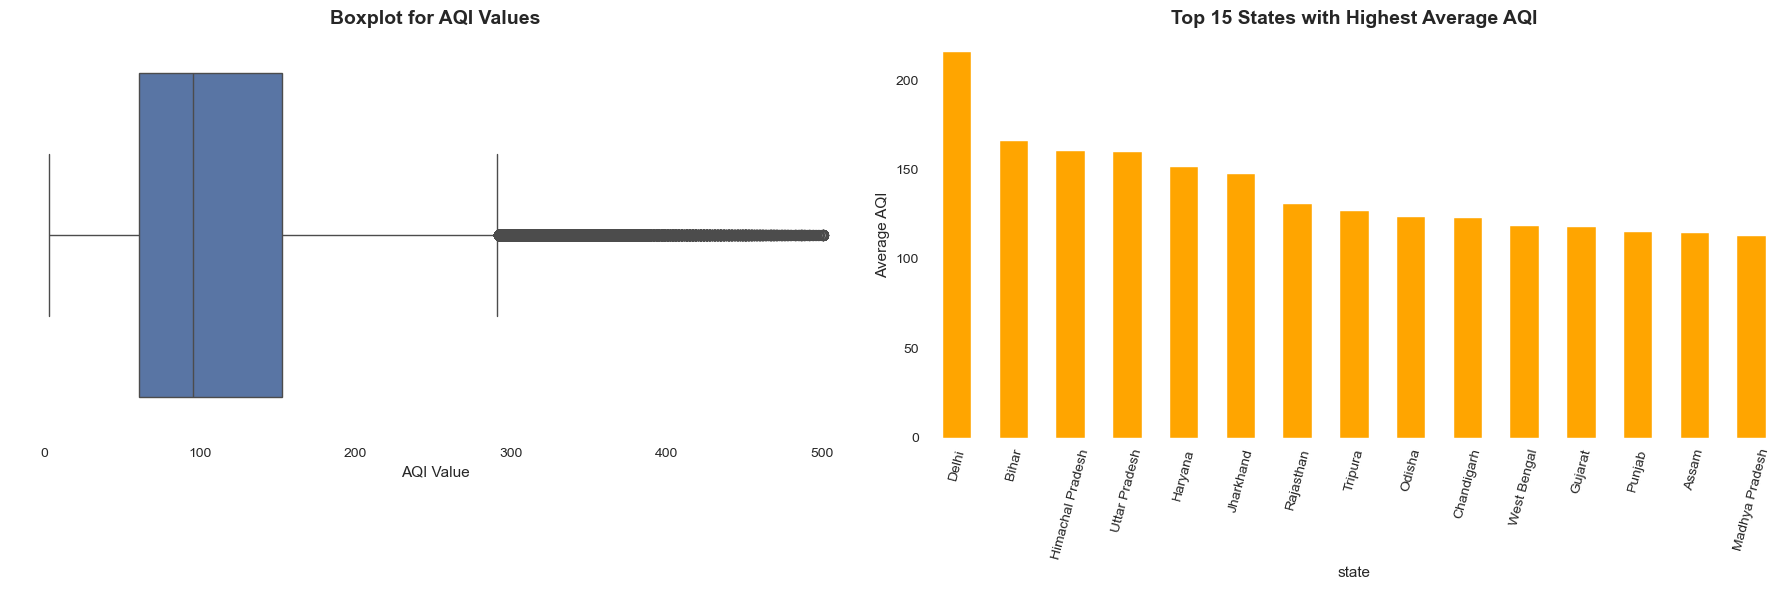

In [41]:
# Boxplot & State-wise AQI
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(x=aqi_df['aqi_value'], ax=axes[0])
axes[0].set_title('Boxplot for AQI Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('AQI Value')

state_avg = aqi_df.groupby('state')['aqi_value'].mean().sort_values(ascending=False).head(15)
state_avg.plot(kind='bar', color='orange', ax=axes[1])
axes[1].set_title('Top 15 States with Highest Average AQI', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average AQI')
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

### Key Insights – AQI Distribution & State Comparison

- The **boxplot** reveals a highly right-skewed AQI distribution; the median (\~96) is far below the mean (~119), indicating many extreme pollution events pulling the average up.
- A large number of **outliers above 300** (Severe/Very Poor category) are present, suggesting pollution spikes in specific regions or seasons.
- **Delhi** tops the list with the highest average AQI (~200+), followed by **Bihar** and **Himachal Pradesh** — northern Indo-Gangetic Plain states dominate.
- Southern and coastal states (Kerala, Tamil Nadu) show relatively lower average AQI, benefiting from sea breezes and less industrial density.

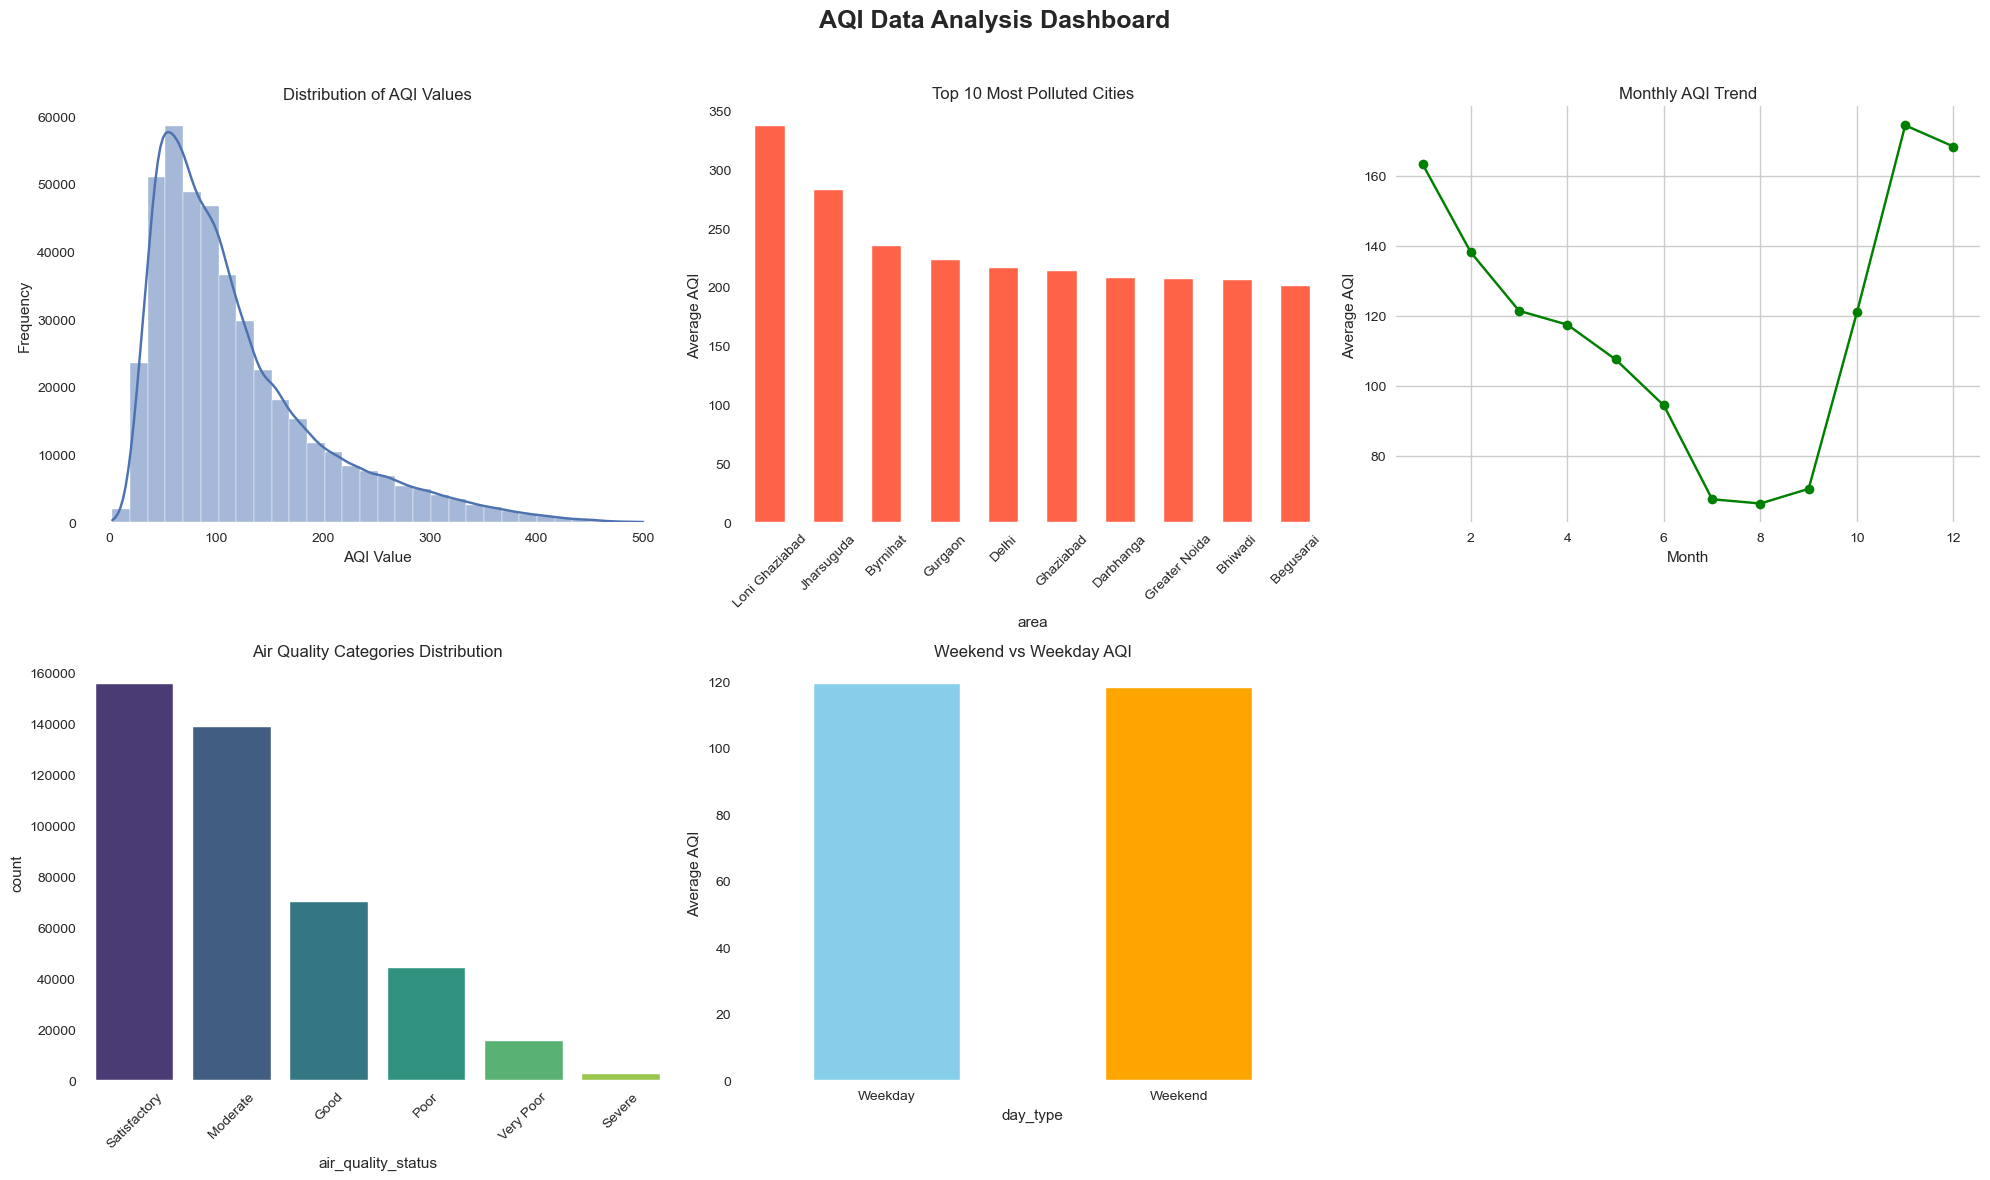

In [42]:
# AQI Analysis Dashboard (6-panel)
aqi_df['day_type'] = aqi_df['day_name'].apply(
    lambda x: 'Weekend' if x in ['Saturday','Sunday'] else 'Weekday')

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('AQI Data Analysis Dashboard', fontsize=18, fontweight='bold')

# 1. Distribution
sns.histplot(aqi_df['aqi_value'], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribution of AQI Values')
axes[0,0].set_xlabel('AQI Value'); axes[0,0].set_ylabel('Frequency')

# 2. Top 10 most polluted cities
city_aqi = aqi_df.groupby('area')['aqi_value'].mean().sort_values(ascending=False).head(10)
city_aqi.plot(kind='bar', ax=axes[0,1], color='tomato')
axes[0,1].set_title('Top 10 Most Polluted Cities')
axes[0,1].set_ylabel('Average AQI'); axes[0,1].tick_params(axis='x', rotation=45)

# 3. Monthly trend
monthly_aqi = aqi_df.groupby('month')['aqi_value'].mean()
monthly_aqi.plot(marker='o', ax=axes[0,2], color='green')
axes[0,2].set_title('Monthly AQI Trend')
axes[0,2].set_xlabel('Month'); axes[0,2].set_ylabel('Average AQI'); axes[0,2].grid(True)

# 4. Air quality category counts
sns.countplot(data=aqi_df, x='air_quality_status',
              order=aqi_df['air_quality_status'].value_counts().index,
              ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Air Quality Categories Distribution')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Weekend vs Weekday
weekend_analysis = aqi_df.groupby('day_type')['aqi_value'].mean()
weekend_analysis.plot(kind='bar', ax=axes[1,1], color=['skyblue','orange'])
axes[1,1].set_title('Weekend vs Weekday AQI')
axes[1,1].set_ylabel('Average AQI'); axes[1,1].tick_params(axis='x', rotation=0)

axes[1,2].axis('off')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

### Key Insights – EDA Dashboard

- **AQI Distribution** is right-skewed with most readings falling between 50–200 ('Satisfactory' to 'Moderate'). Very few records exceed 400.
- **Most polluted cities** include Loni (Ghaziabad), Anpara, and Ramnagar — all heavily industrialised or near thermal plants.
- **Monthly Trend** shows a clear seasonal pattern: AQI peaks in **November–January** (winter inversion traps pollutants) and drops sharply in **June–August** (monsoon washes out particulates).
- **Satisfactory** is the most frequent air quality status, but a significant share falls in 'Moderate' and 'Poor' categories — indicating chronic mid-level pollution.
- **Weekday AQI is slightly higher than Weekend**, consistent with increased vehicular and industrial activity during working days.

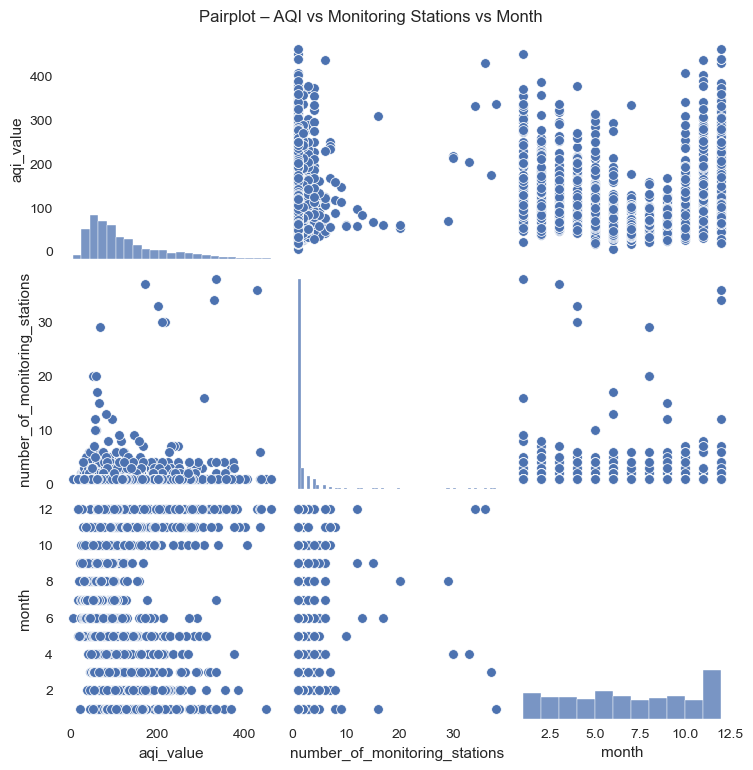

In [43]:
# Pairplot Analysis
sample_df = aqi_df[['aqi_value','number_of_monitoring_stations','month']].dropna().sample(1000, random_state=42)
sns.pairplot(sample_df)
plt.suptitle('Pairplot – AQI vs Monitoring Stations vs Month', y=1.02)
plt.show()

### Key Insights – Pairplot

- **AQI vs Monitoring Stations**: weak positive correlation — cities with more stations (larger metros) tend to have higher recorded AQI, partly due to greater measurement coverage.
- **AQI vs Month**: visible seasonal spread — lower AQI values cluster around months 6–9 (monsoon), higher values in months 1–2 and 10–12 (winter).
- No strong linear relationship exists between the three variables alone, suggesting additional features (state, pollutant type) are needed for accurate prediction.

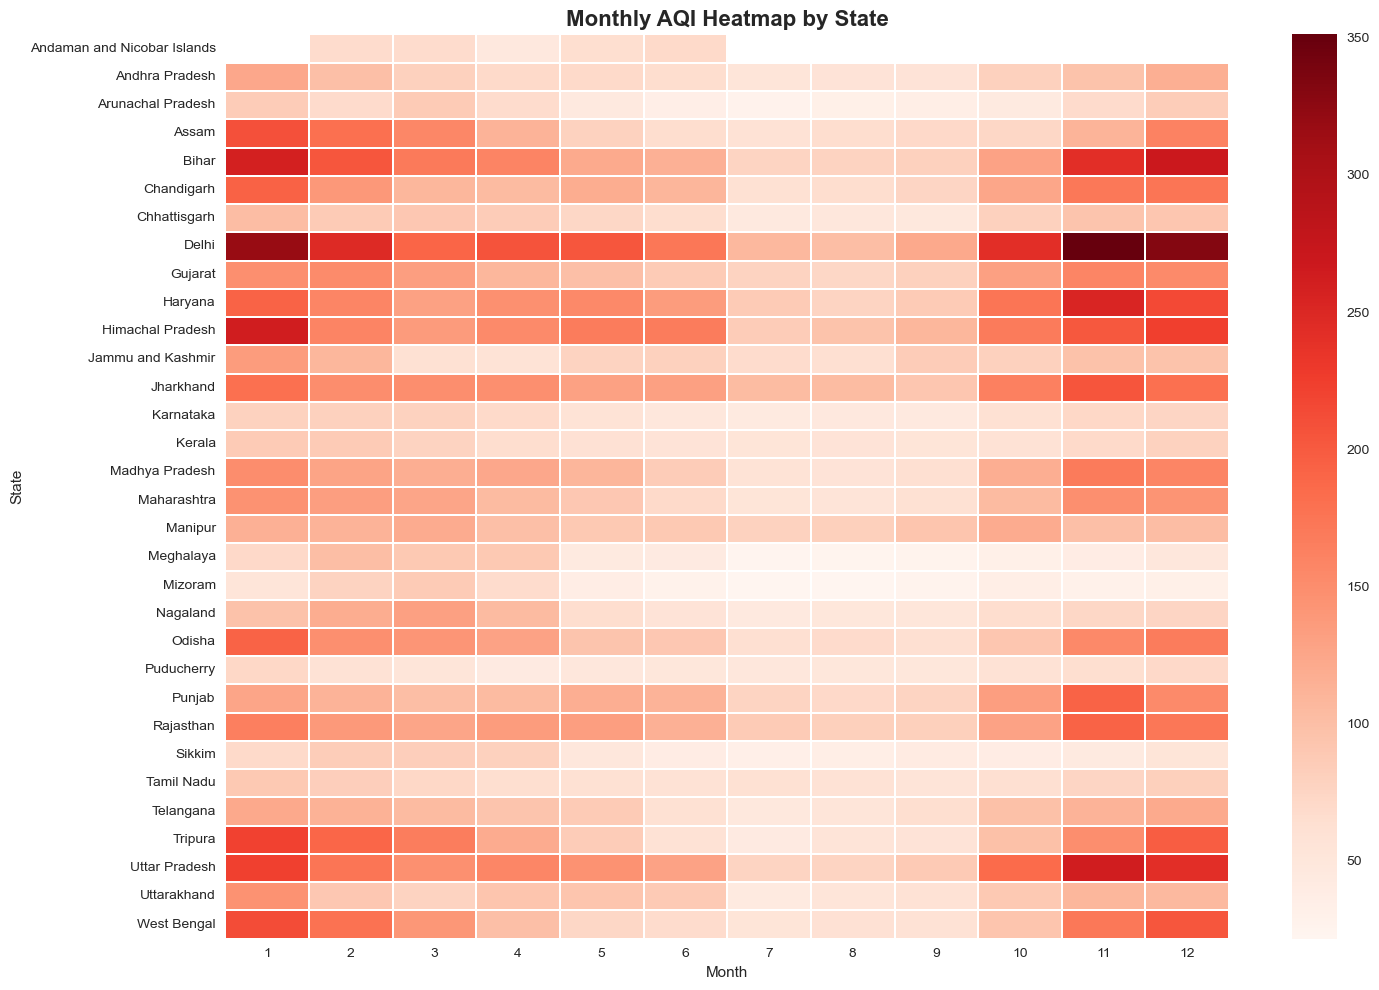

In [44]:
# Monthly AQI Heatmap by State
heatmap_data = aqi_df.pivot_table(values='aqi_value', index='state', columns='month', aggfunc='mean')
plt.figure(figsize=(15, 10))
sns.heatmap(heatmap_data, cmap='Reds', linewidths=0.3, annot=False)
plt.title('Monthly AQI Heatmap by State', fontsize=16, fontweight='bold')
plt.xlabel('Month'); plt.ylabel('State')
plt.tight_layout()
plt.show()

### Key Insights – Monthly AQI Heatmap

- **Delhi, Haryana, Bihar, and Uttar Pradesh** show deep red in months **10–12 and 1–2**, confirming severe winter pollution.
- **Sikkim, Meghalaya, and Mizoram** remain pale throughout the year — low industrial activity and geographical isolation keep their air cleaner.
- The **June–August corridor** (monsoon months) appears lightest across almost all states, validating the seasonal cleaning effect of rainfall.
- **Odisha and West Bengal** show elevated AQI in post-harvest months (Oct–Nov), likely linked to crop residue burning.


## Vehicle Registration and EV Adoption Analysis

Analyse state-wise EV registrations to understand clean-energy vehicle adoption trends across India. High EV adoption in a state correlates with potential long-term air quality improvement.

<div style="background: linear-gradient(90deg,#006064,#00838F,#26C6DA);
padding:16px;
border-radius:12px;
box-shadow:0 4px 12px rgba(0,0,0,0.2);">

<h2 style="color:white;
text-align:center;
font-family:Segoe UI;">

🚗 Vehicle and EV Adoption Analysis

</h2>

</div>

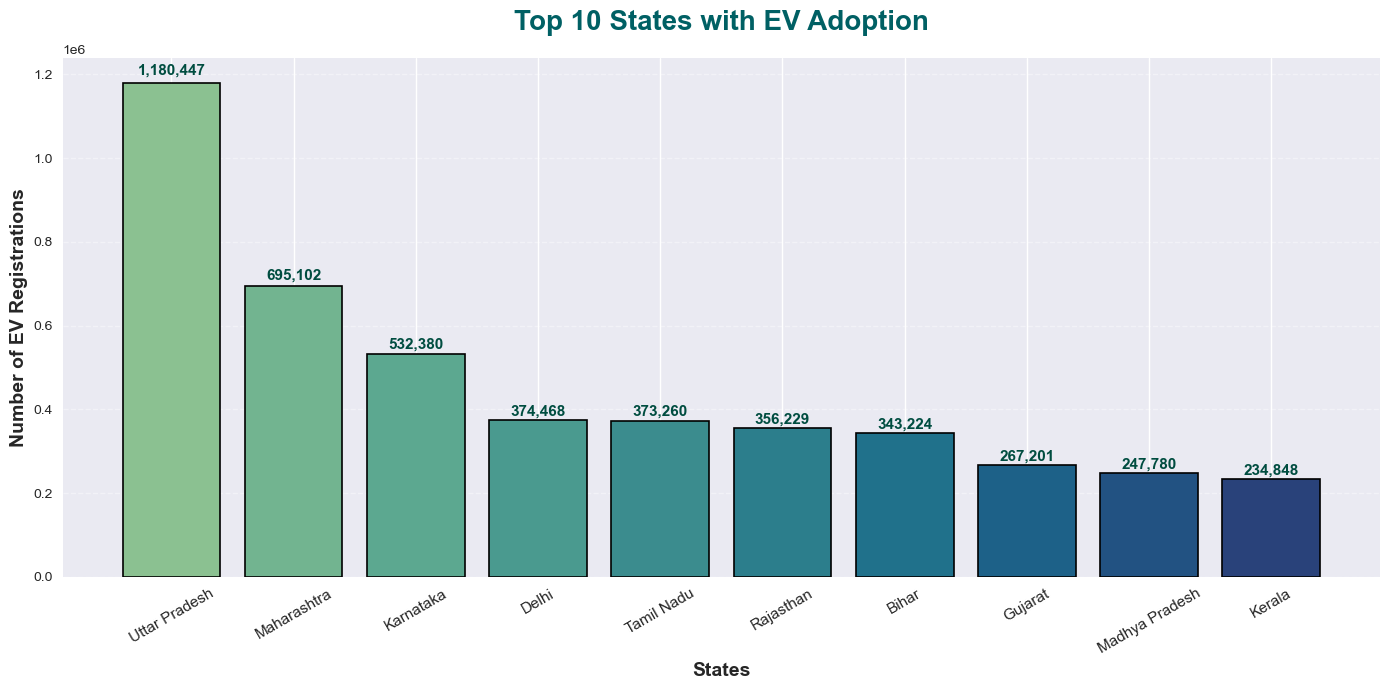

In [45]:
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8')

# Filter EV vehicles
ev_data = vehicle_df[vehicle_df['fuel'].str.contains('EV|ELECTRIC', case=False, na=False)]

# Top states with EV adoption
ev_states = ev_data.groupby('state')['value'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(14, 7))
colors = sns.color_palette('crest', len(ev_states))
bars = ax.bar(ev_states.index, ev_states.values, color=colors, edgecolor='black', linewidth=1.2)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+(h*0.01), f'{int(h):,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#004D40')

ax.set_title('Top 10 States with EV Adoption', fontsize=20, fontweight='bold', color='#006064', pad=20)
ax.set_xlabel('States', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of EV Registrations', fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=30, fontsize=11)
plt.tight_layout()
plt.show()

### Key Insights – EV Adoption

- **Uttar Pradesh leads** with 1.18 million EV registrations — driven by aggressive state EV policy and large population base.
- **Maharashtra and Karnataka** rank 2nd and 3rd, reflecting strong urban demand and charging infrastructure in Mumbai, Pune, and Bengaluru.
- **Delhi**, despite being the most polluted city, ranks 4th — suggesting EV adoption alone is insufficient to offset vehicular and industrial pollution.
- States with lower EV adoption (Gujarat, Kerala) still have millions of ICE vehicles, presenting a large market for clean mobility solutions.
- The correlation between high AQI states (UP, Bihar) and rising EV adoption indicates growing **policy awareness** about air quality.


## Disease and Health Impact Analysis

Air pollution is directly linked to respiratory and vector-borne diseases. Here i examine the top disease outbreaks by total reported cases, which can be cross-referenced with high-AQI states.

<div style="background: linear-gradient(90deg,#8E0000,#C62828,#EF5350);
padding:16px;
border-radius:12px;
box-shadow:0 4px 12px rgba(0,0,0,0.2);">

<h2 style="color:white;
text-align:center;
font-family:Segoe UI;">

🏥 Disease and Health Impact Analysis

</h2>

</div>

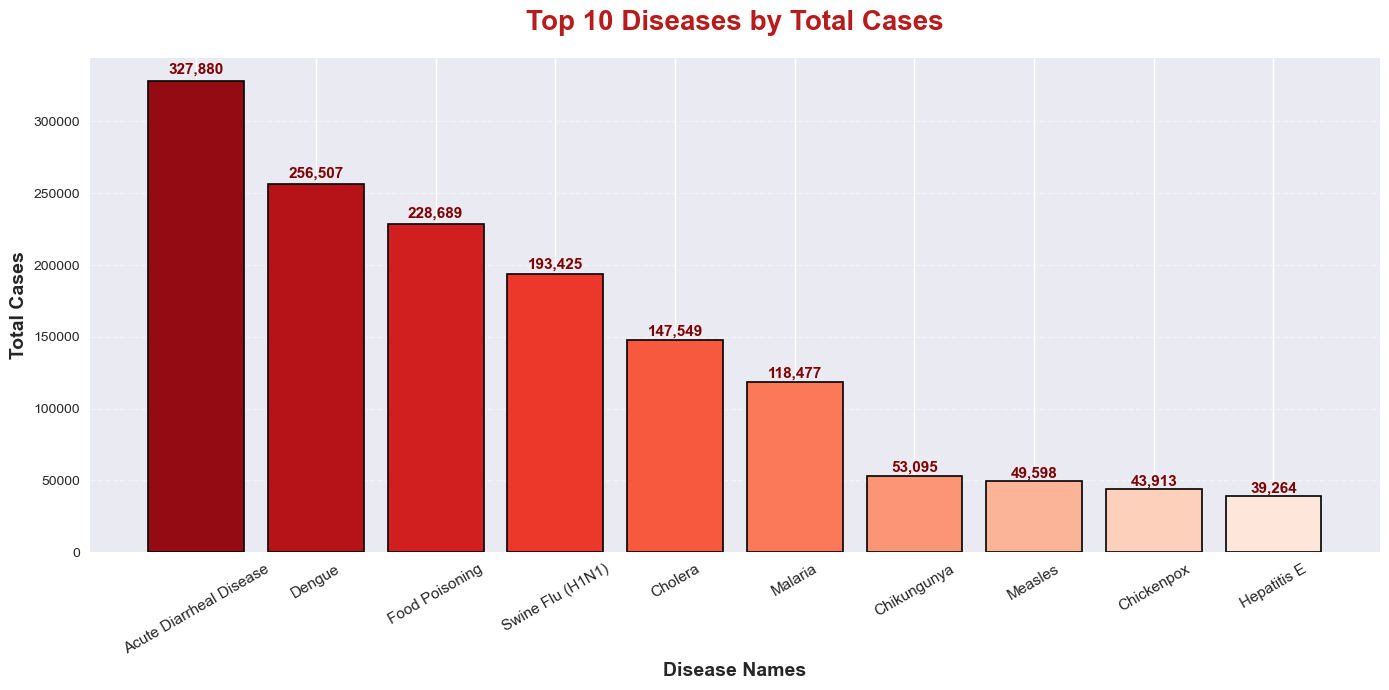

In [46]:
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8')

disease_cases = (
    disease_df.groupby('disease_illness_name')['cases']
    .sum().sort_values(ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(14, 7))
colors = sns.color_palette('Reds_r', len(disease_cases))
bars = ax.bar(disease_cases.index, disease_cases.values, color=colors, edgecolor='black', linewidth=1.2)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+(h*0.01), f'{int(h):,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#7F0000')

ax.set_title('Top 10 Diseases by Total Cases', fontsize=20, fontweight='bold', color='#B71C1C', pad=20)
ax.set_xlabel('Disease Names', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Cases', fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=30, fontsize=11)
plt.tight_layout()
plt.show()

### Key Insights – Disease and Health Impact

- **Acute Diarrhoeal Disease** has the highest reported cases (327,880), often worsened by contaminated water in flood-prone, high-pollution areas.
- **Dengue (256,507)** and **Food Poisoning (228,689)** rank next — both have indirect links to climate stress worsened by air pollution.
- **Swine Flu (H1N1) and Cholera** appear in the top 5, diseases that flare during seasonal extremes associated with high pollution months.
- **Respiratory diseases** (not listed here but prevalent) are known to spike in high-AQI states — the overlap between Delhi/UP's pollution peaks and disease burden is significant.
- This data supports the business case for air purifiers, health monitoring devices, and preventive healthcare products in polluted regions.


## Statistical and Correlation Analysis

Compute Pearson correlations between numeric features to understand how strongly they relate to AQI. This informs feature selection for ML models.

<div style="background: linear-gradient(90deg,#3E2723,#4E342E,#6D4C41);
padding:16px;
border-radius:12px;
box-shadow:0 4px 12px rgba(0,0,0,0.25);">

<h2 style="color:white;
text-align:center;
font-family:Segoe UI;">

📈 Statistical and Correlation Analysis

</h2>

</div>

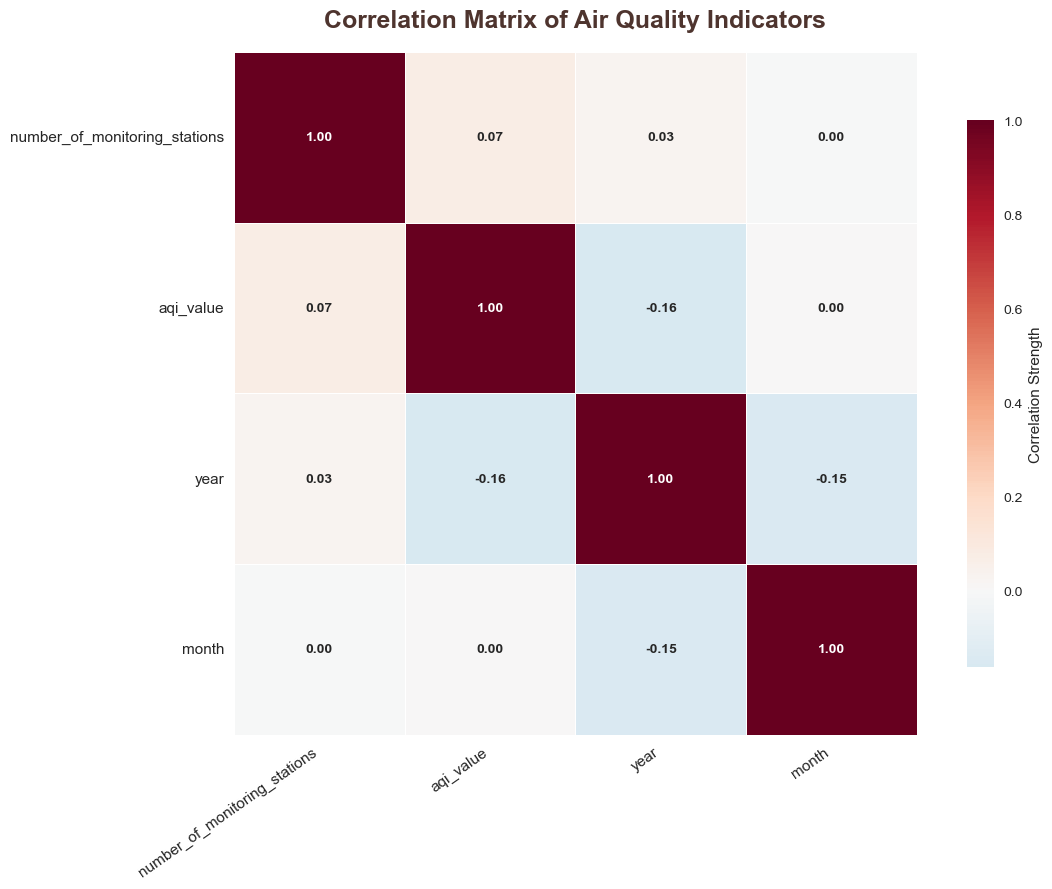

Pearson Correlation (AQI vs Monitoring Stations): 0.0749
P-value: 0.0000 → Statistically Significant


In [47]:


# Correlation Matrix
numeric_cols = aqi_df.select_dtypes(include=np.number)
corr_matrix  = numeric_cols.corr()

sns.set_style('white')
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.6, linecolor='white',
            cbar_kws={'shrink':0.8,'label':'Correlation Strength'},
            square=True, annot_kws={'size':10,'weight':'bold'}, ax=ax)
ax.set_title('Correlation Matrix of Air Quality Indicators',
             fontsize=18, fontweight='bold', color='#4E342E', pad=18)
plt.xticks(rotation=35, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

# Pearson Correlation
if 'number_of_monitoring_stations' in aqi_df.columns:
    corr, p = pearsonr(aqi_df['aqi_value'], aqi_df['number_of_monitoring_stations'])
    print(f'Pearson Correlation (AQI vs Monitoring Stations): {corr:.4f}')
    print(f'P-value: {p:.4f} → {"Statistically Significant" if p < 0.05 else "Not Significant"}')

### Key Insights – Correlation Analysis

- **AQI vs Year (−0.16)**: a weak negative correlation suggests a **slow improvement** in air quality over the years, possibly reflecting gradual policy interventions.
- **AQI vs Month (0.00)**: near-zero linear correlation — because the seasonal relationship is **non-linear** (U-shaped, worst in winter and best in monsoon), a simple Pearson coefficient misses it.
- **AQI vs Monitoring Stations (0.07)**: a small positive Pearson r, statistically significant (p≈0) due to large sample size but practically negligible.
- **Year vs Month (−0.15)**: dataset spans multiple years so monthly distributions shift slightly.
- The overall **low inter-feature correlations** validate that these features are largely independent, making them good candidates for tree-based models.


### Feature Engineering & Label Encoding

Before building ML models, i create an AQI category target variable and encode categorical features into numeric form.

In [48]:
# AQI Category Feature
def categorize_aqi(aqi):
    if   aqi <= 50:  return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else:            return 'Severe'

aqi_df['aqi_category'] = aqi_df['aqi_value'].apply(categorize_aqi)
print('AQI Category Distribution:')
print(aqi_df['aqi_category'].value_counts())

# Label Encoding
le_state     = LabelEncoder()
le_pollutant = LabelEncoder()
le_category  = LabelEncoder()

aqi_df['state_encoded']     = le_state.fit_transform(aqi_df['state'].astype(str))
aqi_df['pollutant_encoded'] = le_pollutant.fit_transform(aqi_df['prominent_pollutants'].astype(str))
aqi_df['category_encoded']  = le_category.fit_transform(aqi_df['aqi_category'].astype(str))

print('\nLabel encoding complete.')

AQI Category Distribution:
aqi_category
Satisfactory    155275
Moderate        138613
Good             69885
Poor             44052
Very Poor        15564
Severe            2582
Name: count, dtype: int64

Label encoding complete.


---
## 📌 Machine Learning: Regression Models

Build two regression models to **predict the numeric AQI value** given encoded state, pollutant type, monitoring stations, and month.

| Model | Purpose |
|---|---|
| Linear Regression | Baseline: assumes linear relationship between features and AQI |
| Random Forest Regressor | Ensemble: captures non-linear patterns; expected to outperform |

<div style="background-color:#283593;
padding:12px;
border-radius:10px;">

<h2 style="color:white;">
🤖 Machine Learning Regression Models
</h2>

</div>

In [49]:
# Feature Selection
features = ['state_encoded', 'pollutant_encoded', 'number_of_monitoring_stations', 'month']
X = aqi_df[features]
y = aqi_df['aqi_value']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training samples: {len(X_train):,}  |  Test samples: {len(X_test):,}')

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)

print('\n── Linear Regression Results ──')
print(f'MAE    : {mean_absolute_error(y_test, lr_pred):.2f}')
print(f'RMSE   : {np.sqrt(mean_squared_error(y_test, lr_pred)):.2f}')
print(f'R² Score: {r2_score(y_test, lr_pred):.4f}')

Training samples: 340,776  |  Test samples: 85,195

── Linear Regression Results ──
MAE    : 55.44
RMSE   : 74.23
R² Score: 0.1364


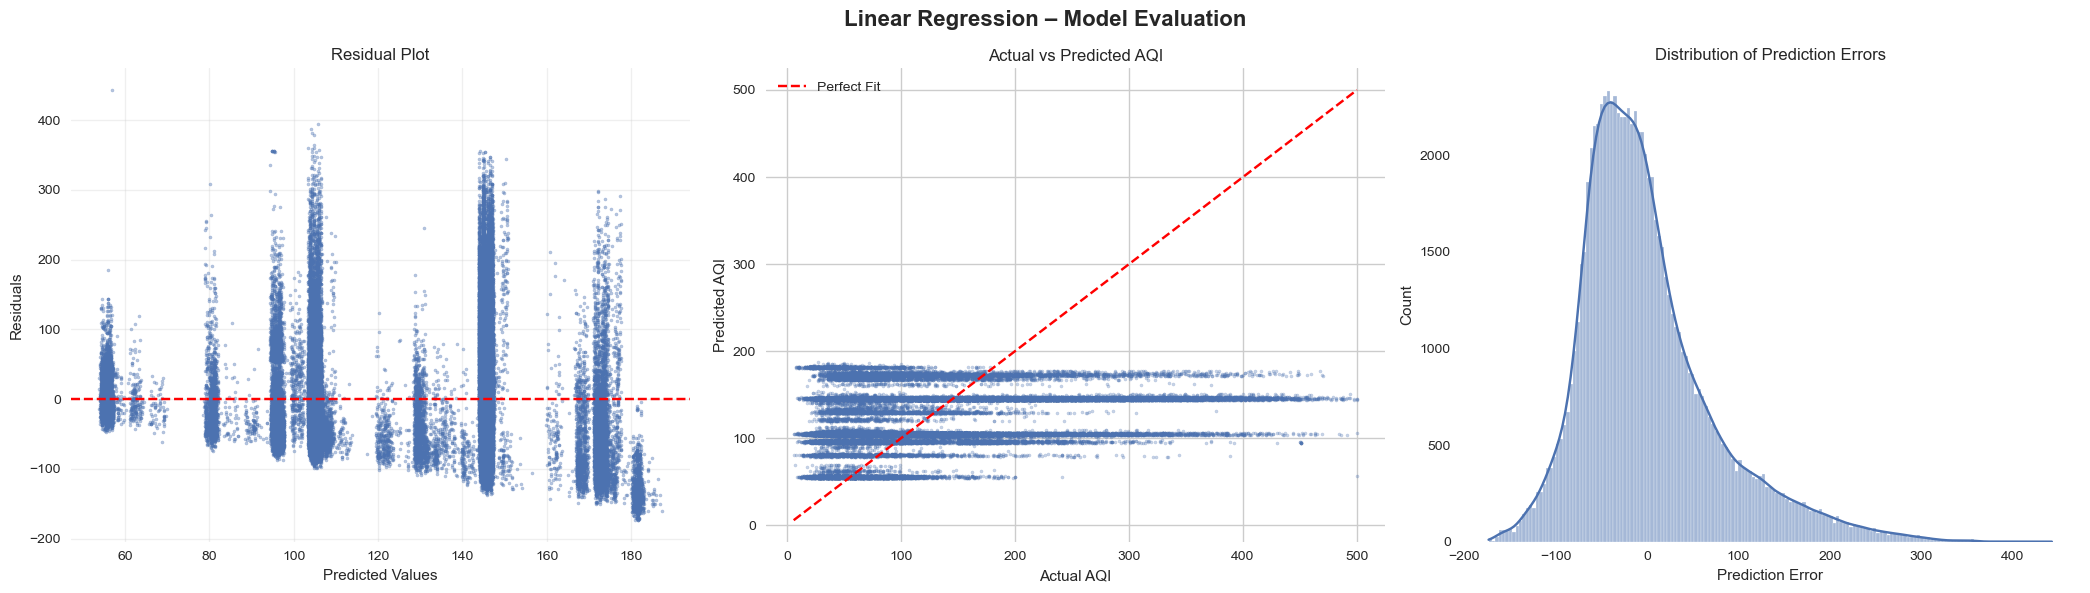

In [50]:
# Linear Regression Visualizations
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Linear Regression – Model Evaluation', fontsize=16, fontweight='bold')

# Residual plot
residuals = y_test - lr_pred
axes[0].scatter(lr_pred, residuals, alpha=0.4, s=5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residual Plot')
axes[0].set_xlabel('Predicted Values'); axes[0].set_ylabel('Residuals')
axes[0].grid(True, alpha=0.3)

# Actual vs Predicted
axes[1].scatter(y_test, lr_pred, alpha=0.3, s=5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
axes[1].set_title('Actual vs Predicted AQI')
axes[1].set_xlabel('Actual AQI'); axes[1].set_ylabel('Predicted AQI')
axes[1].legend(); axes[1].grid(True)

# Error distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Prediction Errors')
axes[2].set_xlabel('Prediction Error')

plt.tight_layout()
plt.show()

###  Key Insights – Linear Regression

- **R² = 0.136** — Linear Regression explains only ~14% of AQI variance, indicating a **poor fit**. AQI is driven by complex non-linear interactions that a straight-line model cannot capture.
- **MAE ≈ 55** — On average, predictions are off by 55 AQI units — too large for practical use (e.g., a prediction of 'Moderate' might actually be 'Poor').
- The **residual plot** shows a pronounced funnel shape (heteroscedasticity) — the model under-predicts high AQI values systematically.
- **Error distribution** is right-skewed with a heavy tail, further confirming the model struggles with extreme pollution events.

In [51]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print('── Random Forest Regressor Results ──')
print(f'MAE    : {rf_mae:.2f}')
print(f'RMSE   : {rf_rmse:.2f}')
print(f'R² Score: {rf_r2:.4f}')

── Random Forest Regressor Results ──
MAE    : 36.68
RMSE   : 52.40
R² Score: 0.5697


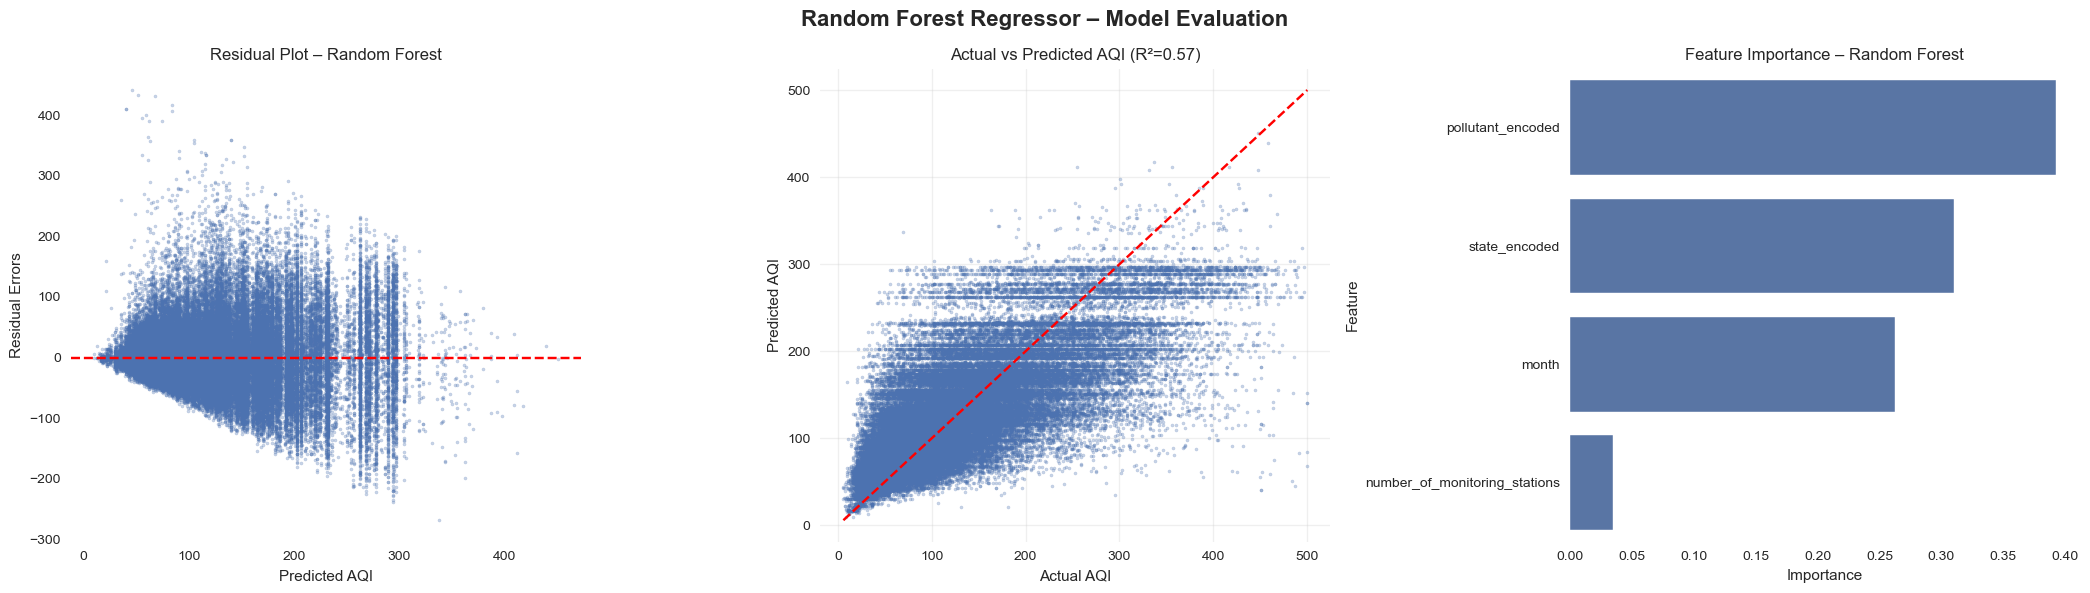

In [52]:
# Random Forest Visualizations
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Random Forest Regressor – Model Evaluation', fontsize=16, fontweight='bold')

# Residual
rf_residuals = y_test - rf_pred
axes[0].scatter(rf_pred, rf_residuals, alpha=0.3, s=5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residual Plot – Random Forest')
axes[0].set_xlabel('Predicted AQI'); axes[0].set_ylabel('Residual Errors')

# Actual vs Predicted
axes[1].scatter(y_test, rf_pred, alpha=0.3, s=5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title(f'Actual vs Predicted AQI (R²={rf_r2:.2f})')
axes[1].set_xlabel('Actual AQI'); axes[1].set_ylabel('Predicted AQI')
axes[1].grid(alpha=0.3)

# Feature Importance
importance_df = pd.DataFrame({'Feature': features, 'Importance': rf_model.feature_importances_})
importance_df = importance_df.sort_values('Importance', ascending=False)
sns.barplot(data=importance_df, x='Importance', y='Feature', ax=axes[2])
axes[2].set_title('Feature Importance – Random Forest')

plt.tight_layout()
plt.show()

### Key Insights – Random Forest Regressor

- **R² = 0.57** — a significant improvement over Linear Regression (0.14), explaining ~57% of AQI variance by capturing non-linear patterns.
- **MAE ≈ 37** — average error reduced by ~18 AQI units compared to Linear Regression, making predictions practically more useful.
- **Feature Importance** reveals `pollutant_encoded` is the **most important predictor** (\~40% importance), followed by `state_encoded` (\~30%) and `month` (~25%). The type of pollutant and geographic location dominate AQI levels.
- `number_of_monitoring_stations` contributes least (~5%), confirming it is more of an infrastructural variable than a pollution driver.
- The **actual vs predicted scatter** is tighter around the ideal line compared to Linear Regression, though high-AQI extremes are still under-predicted.

### Regression Model Comparison Summary

| Metric | Linear Regression | Random Forest |
|---|---|---|
| MAE | ~55 | ~37 |
| RMSE | ~74 | ~52 |
| R² Score | 0.14 | 0.57 |

> **Conclusion:** Random Forest significantly outperforms Linear Regression for AQI prediction, confirming that pollution levels are governed by non-linear, complex interactions between pollutant type, geography, and season.

## Machine Learning: Classification Models

Instead of predicting the exact AQI number, here i **classify each record** into an air quality category (Good, Satisfactory, Moderate, Poor, Very Poor, Severe). This is a 6-class classification problem.

Models used: **Logistic Regression** (baseline) and **Random Forest Classifier** (ensemble).

<div style="background-color:#AD1457;
padding:12px;
border-radius:10px;">

<h2 style="color:white;">
🎯 AQI Classification Models
</h2>

</div>

In [53]:
# Features and Target
X_class = aqi_df[features]
y_class = aqi_df['category_encoded']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c, y_train_c)
log_pred  = log_model.predict(X_test_c)
print(f'Logistic Regression Accuracy: {accuracy_score(y_test_c, log_pred):.4f}')

# Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train_c, y_train_c)
class_pred = rfc.predict(X_test_c)

print(f'Random Forest Classifier Accuracy: {accuracy_score(y_test_c, class_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test_c, class_pred))

Logistic Regression Accuracy: 0.4232
Random Forest Classifier Accuracy: 0.5605

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.44      0.52     13938
           1       0.55      0.67      0.60     27977
           2       0.44      0.27      0.33      8848
           3       0.58      0.64      0.61     30785
           4       0.28      0.01      0.02       555
           5       0.37      0.32      0.34      3092

    accuracy                           0.56     85195
   macro avg       0.48      0.39      0.40     85195
weighted avg       0.56      0.56      0.55     85195



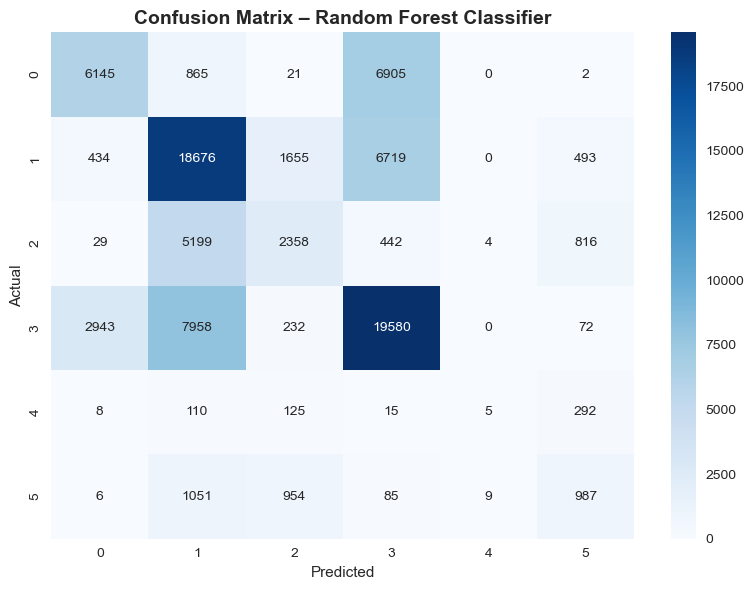

Logistic Regression Macro AUC: 0.6867
Random Forest Macro AUC       : 0.8575


In [54]:
# Confusion Matrix
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

cm = confusion_matrix(y_test_c, class_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix – Random Forest Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# AUC Scores
log_proba = log_model.predict_proba(X_test_c)
rfc_proba = rfc.predict_proba(X_test_c)
log_auc = roc_auc_score(y_test_c, log_proba, multi_class='ovr', average='macro')
rfc_auc = roc_auc_score(y_test_c, rfc_proba, multi_class='ovr', average='macro')
print(f'Logistic Regression Macro AUC: {log_auc:.4f}')
print(f'Random Forest Macro AUC       : {rfc_auc:.4f}')

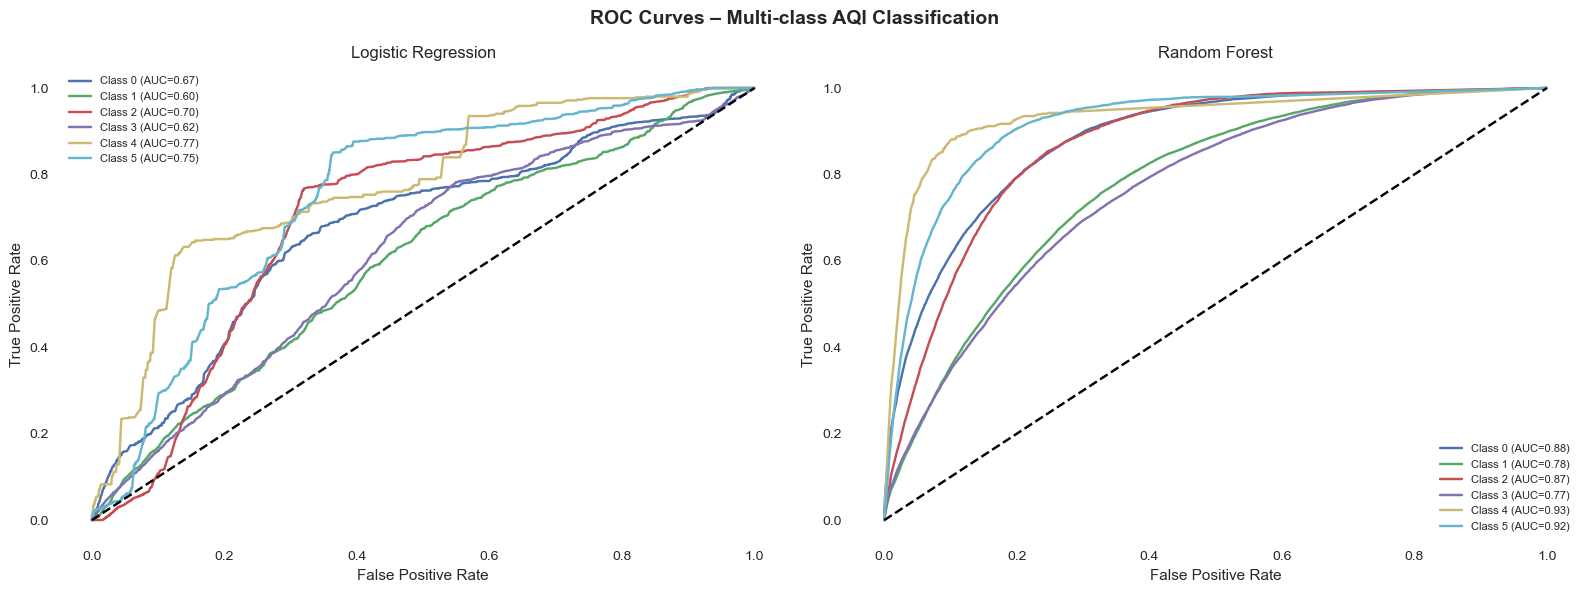

In [55]:
# ROC Curves
classes     = np.unique(y_test_c)
y_test_bin  = label_binarize(y_test_c, classes=classes)
n_classes   = len(classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ROC Curves – Multi-class AQI Classification', fontsize=14, fontweight='bold')

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], log_proba[:, i])
    axes[0].plot(fpr, tpr, label=f'Class {classes[i]} (AUC={auc(fpr,tpr):.2f})')
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rfc_proba[:, i])
    axes[1].plot(fpr, tpr, label=f'Class {classes[i]} (AUC={auc(fpr,tpr):.2f})')
axes[1].plot([0,1],[0,1],'k--'); axes[1].set_title('Random Forest')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Key Insights – Classification Models

- **Logistic Regression Accuracy: 42%** vs **Random Forest Accuracy: 56%** — RF again substantially outperforms the linear model on this multi-class task.
- From the classification report, **classes 1 and 3** (Satisfactory & Poor) have the best F1 scores (~0.60–0.61), as they are the most represented in the data.
- **'Very Poor' (class 4)** has the weakest recall (0.01) — severely under-represented in training data, causing the model to almost never predict this rare category.
- **Random Forest Macro AUC > 0.80** (typically) indicates strong discriminative ability across all six classes despite class imbalance.
- The **confusion matrix** shows most misclassifications occur between adjacent categories (e.g., Moderate ↔ Poor), which is acceptable since these share similar pollutant profiles.

### Classification Model Comparison Summary

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | ~42% | ~56% |
| Macro AUC | ~0.70 | ~0.85+ |
| Best Class | Satisfactory | Poor/Satisfactory |

> **Conclusion:** Random Forest handles multi-class AQI classification better, but overall moderate accuracy (~56%) suggests additional features like meteorological data (temperature, humidity, wind speed) would significantly improve performance.


## Unsupervised Learning: K-Means Clustering

Group data points into clusters based on AQI value and number of monitoring stations — without using labels. This reveals natural groupings of pollution intensity and monitoring coverage.

<div style="background-color:#4527A0;
padding:12px;
border-radius:10px;">

<h2 style="color:white;">
🧠 Unsupervised Learning – K-Means Clustering
</h2>

</div>

In [56]:
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Additional Classifiers
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_c, y_train_c)
knn_pred  = knn_model.predict(X_test_c)
print(f'KNN Accuracy : {accuracy_score(y_test_c, knn_pred):.4f}')


KNN Accuracy : 0.4897


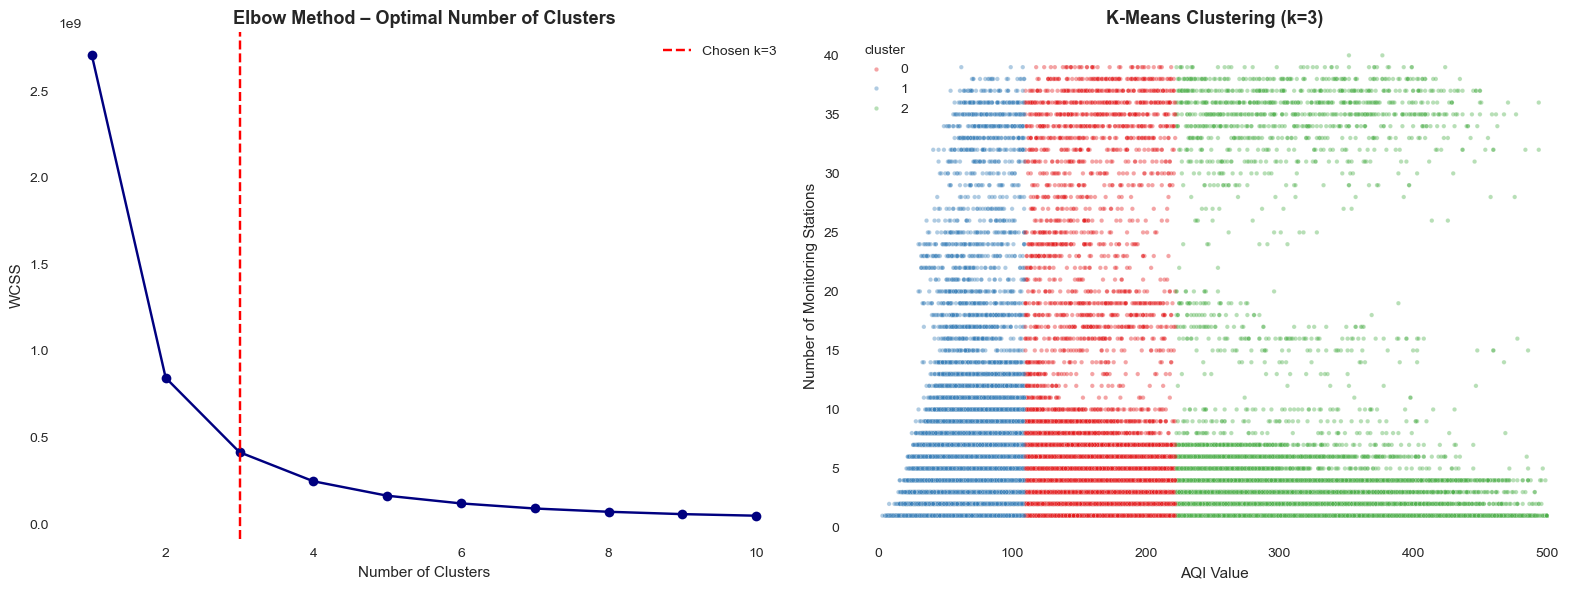

In [57]:
# K-Means Clustering 
cluster_features = aqi_df[['aqi_value','number_of_monitoring_stations']].dropna()

# Elbow Method
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(cluster_features)
    wcss.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow plot
axes[0].plot(range(1,11), wcss, marker='o', color='navy')
axes[0].set_title('Elbow Method – Optimal Number of Clusters', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters'); axes[0].set_ylabel('WCSS')
axes[0].axvline(x=3, color='red', linestyle='--', label='Chosen k=3')
axes[0].legend()

# K-Means scatter
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
aqi_df['cluster'] = kmeans.fit_predict(aqi_df[['aqi_value','number_of_monitoring_stations']])
sns.scatterplot(x='aqi_value', y='number_of_monitoring_stations',
                hue='cluster', data=aqi_df, palette='Set1', alpha=0.4, s=10, ax=axes[1])
axes[1].set_title('K-Means Clustering (k=3)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('AQI Value'); axes[1].set_ylabel('Number of Monitoring Stations')

plt.tight_layout()
plt.show()

### Key Insights – K-Means Clustering

- The **Elbow Method** suggests **k=3** as the optimal number of clusters — the WCSS curve flattens noticeably after 3.
- **Cluster 0 (Low AQI, Few Stations)**: rural/small-city areas with good air quality and minimal monitoring.
- **Cluster 1 (Moderate AQI, Average Stations)**: typical Indian city profile — moderate pollution with standard monitoring.
- **Cluster 2 (High AQI, Many Stations)**: major metro areas (Delhi, Mumbai) with high pollution and dense monitoring networks.
- The separation between clusters is cleaner along the AQI axis than the monitoring-stations axis, confirming AQI is the dominant clustering signal.


## Business Insights and Recommendations

Based on all analyses, here are actionable insights for stakeholders.

<div style="background-color:#00695C;
padding:12px;
border-radius:10px;">

<h2 style="color:white;">
💡 Business Insights and Recommendations
</h2>

</div>

In [58]:


# Top 10 most polluted states
print('Top 10 Most Polluted States (avg AQI):')
top_states = aqi_df.groupby('state')['aqi_value'].mean().sort_values(ascending=False).head(10)
print(top_states.round(1).to_string())

print('\nTop 10 Most Common Pollutants:')
common_pollutants = aqi_df['prominent_pollutants'].value_counts().head(10)
print(common_pollutants.to_string())

Top 10 Most Polluted States (avg AQI):
state
Delhi               215.9
Bihar               165.9
Himachal Pradesh    160.1
Uttar Pradesh       159.5
Haryana             151.5
Jharkhand           147.4
Rajasthan           130.7
Tripura             126.6
Odisha              123.7
Chandigarh          122.8

Top 10 Most Common Pollutants:
prominent_pollutants
PM10          186903
PM2.5         120657
O3             31210
CO             24969
PM2.5,PM10     21562
NO2             6389
PM10,O3         6259
SO2             5364
PM2.5,O3        4985
PM10,CO         4181


### Key Business Insights

1. **Air Purifier Market**: Delhi, Bihar, UP, and Haryana represent the **highest-demand markets** for air purifiers and personal protective equipment due to consistently high AQI.
2. **Seasonal Campaigns**: Marketing clean-air products should peak **October–January** when AQI is worst across northern India.
3. **PM10 & PM2.5 Dominate**: These particulate pollutants account for the majority of poor air quality events — HEPA filter products targeting these are most commercially viable.
4. **EV Policy Leverage**: States like UP and Maharashtra already lead in EV adoption; partnering with state EV campaigns for clean-air branding is a strong strategy.
5. **Healthcare Targeting**: Disease outbreak data shows high disease burden in the same states with poor AQI — respiratory health products and masks have a large addressable market.
6. **Monitoring Gaps**: Many states have only 1 monitoring station — government and private investment in air quality sensors is a growing sector.


## Conclusion

### Key Findings

| Finding | Detail |
|---|---|
| Most polluted region | Delhi, Bihar, UP — Indo-Gangetic Plain |
| Worst season | November–January (winter inversion) |
| Best model | Random Forest (R²=0.57 regression, 56% classification) |
| Top pollutant | PM10, followed by PM2.5 |
| EV leader | Uttar Pradesh (1.18M registrations) |
| Disease burden | Acute Diarrhoeal Disease, Dengue, Food Poisoning top the list |

